In [1]:
!pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.0 MB/s eta 0:00:00


In [2]:
import os
import torch
import torch.nn.functional as F
from torchvision import transforms
import torchmetrics
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
!git clone https://github.com/facebookresearch/dinov3.git
!cp dinov3/hubconf.py .

Cloning into 'dinov3'...
remote: Enumerating objects: 579, done.
remote: Counting objects: 100% (445/445), done.
remote: Compressing objects: 100% (337/337), done.
remote: Total 579 (delta 234), reused 108 (delta 108), pack-reused 134 (from 2)
Receiving objects: 100% (579/579), 12.44 MiB | 19.44 MiB/s, done.
Resolving deltas: 100% (248/248), done.


In [5]:
import sys
sys.path.append("dinov3")

In [6]:
!wget http://www.agentspace.org/download/mydinov3.zip
!unzip -P dino mydinov3.zip

--2026-03-27 15:21:41--  http://www.agentspace.org/download/mydinov3.zip
Resolving www.agentspace.org (www.agentspace.org)... 62.168.101.9
Connecting to www.agentspace.org (www.agentspace.org)|62.168.101.9|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.agentspace.org/download/mydinov3.zip [following]
--2026-03-27 15:21:42--  https://www.agentspace.org/download/mydinov3.zip
Connecting to www.agentspace.org (www.agentspace.org)|62.168.101.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80324355 (77M) [application/zip]
Saving to: ‘mydinov3.zip’

mydinov3.zip        100%[===================>]  76.60M  8.38MB/s    in 8.0s    

2026-03-27 15:21:50 (9.59 MB/s) - ‘mydinov3.zip’ saved [80324355/80324355]

Archive:  mydinov3.zip
  inflating: dinov3_vits16_pretrain_lvd1689m.pth  


In [7]:
backbone = torch.hub.load('.', 'dinov3_vits16', source='local', weights='dinov3_vits16_pretrain_lvd1689m.pth') # dinov3_vits16
backbone.to(device)
backbone.eval()

Downloading: "file:///content/dinov3_vits16_pretrain_lvd1689m.pth" to /root/.cache/torch/hub/checkpoints/dinov3_vits16_pretrain_lvd1689m.pth


100%|██████████| 82.5M/82.5M [00:00<00:00, 1.71GB/s]


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerN

In [8]:
def make_transform(resize_size = 768):
    to_tensor = transforms.ToTensor()
    resize = transforms.Resize((resize_size, resize_size), antialias=True)
    normalize = transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    )
    return transforms.Compose([to_tensor, resize, normalize])

img_size = 768
transform = make_transform(img_size)

In [9]:
!pip install fastncut

In [10]:
from fastncut import ncut, toCosSin, extendWithFix

In [11]:
!wget http://agentspace.org/download/cup845972797.png

--2026-03-27 15:21:58--  http://agentspace.org/download/cup845972797.png
Resolving agentspace.org (agentspace.org)... 62.168.101.9
Connecting to agentspace.org (agentspace.org)|62.168.101.9|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.agentspace.org/download/cup845972797.png [following]
--2026-03-27 15:21:59--  https://www.agentspace.org/download/cup845972797.png
Resolving www.agentspace.org (www.agentspace.org)... 62.168.101.9
Connecting to www.agentspace.org (www.agentspace.org)|62.168.101.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 268120 (262K) [image/png]
Saving to: ‘cup845972797.png’

cup845972797.png    100%[===================>] 261.84K   419KB/s    in 0.6s    

2026-03-27 15:22:01 (419 KB/s) - ‘cup845972797.png’ saved [268120/268120]



In [12]:
image = cv2.imread("cup845972797.png")

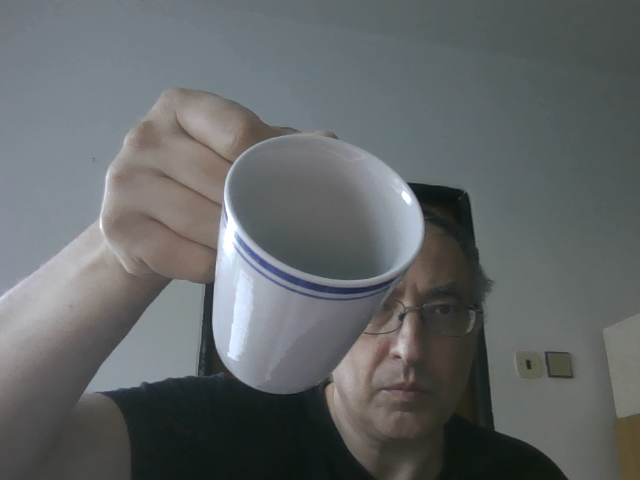

In [13]:
cv2_imshow(image)

In [14]:
def cv2_imshow_mask(image, mask):
    overlay = image.copy()
    overlay[mask > 0] = (0,255,255)
    result = cv2.addWeighted(overlay, 0.4, image, 0.6, 0)
    cv2_imshow(result)

In [15]:
def fix_polarity(binary):
    corners = np.array([ binary[0,0], binary[0,-1], binary[-1,0], binary[-1,-1] ], np.float32) / 255
    if np.average(corners) < 0.5:
        return binary
    else:
        print("inverted")
        return ~binary

Our method

In [18]:
with torch.no_grad():
    blob = transform(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)).unsqueeze(0).to(device)
    feats = backbone.get_intermediate_layers(blob,norm=False)[0]
    feats = feats.view(feats.shape[0],blob.shape[2]//backbone.patch_size,blob.shape[3]//backbone.patch_size,feats.shape[-1])
    feats = feats.permute(0,3,1,2)
    feats = F.interpolate(feats, size=(image.shape[0], image.shape[1]), mode="bilinear", align_corners=False)
    bipartition0 = ncut(feats, data_format="bchw", num_iters=4)[0]
    bipartition = bipartition0.cpu().numpy().astype(np.uint8)*255

In [26]:
feats.min(), feats.max()

(tensor(-187.0242, device='cuda:0'), tensor(441.3867, device='cuda:0'))

In [27]:
feats.shape

torch.Size([1, 384, 480, 640])

inverted


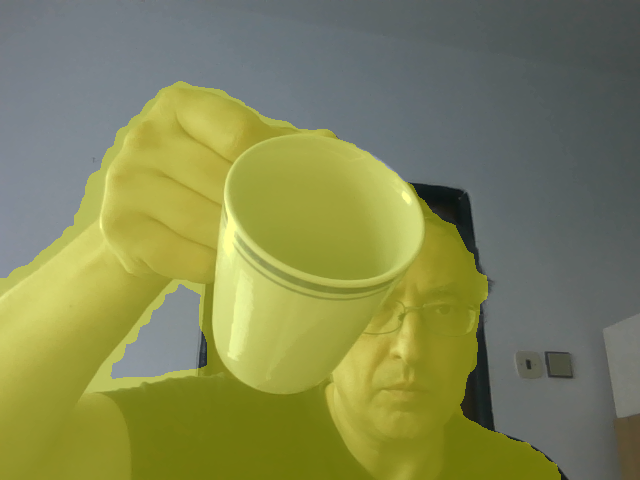

In [19]:
cv2_imshow_mask(image, fix_polarity(bipartition))

In [20]:
bipartition1 = ncut(feats, data_format="bchw", num_iters=4, mask=~bipartition0)[0]
bipartition = bipartition1.cpu().numpy().astype(np.uint8)*255

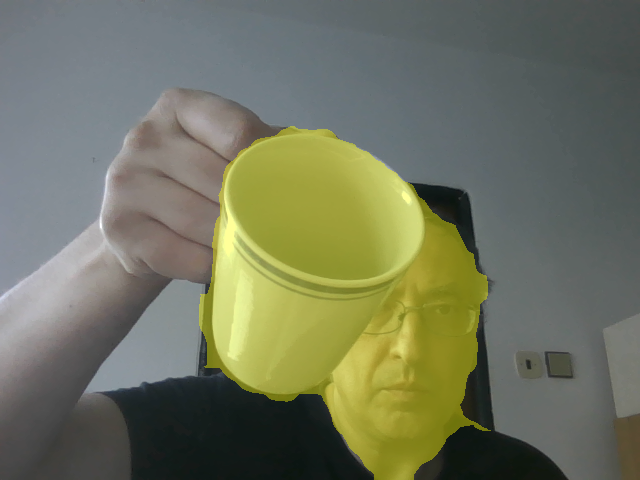

In [21]:
cv2_imshow_mask(image, fix_polarity(bipartition))

In [22]:
bipartition2 = ncut(feats, data_format="bchw", num_iters=4, mask=bipartition1)[0]
bipartition = bipartition2.cpu().numpy().astype(np.uint8)*255

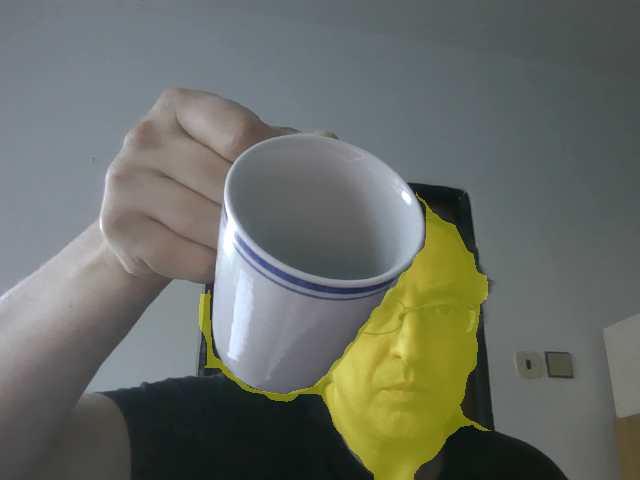

In [23]:
cv2_imshow_mask(image, fix_polarity(bipartition))

In [24]:
bipartition = (bipartition1 & ~bipartition2).cpu().numpy().astype(np.uint8)*255

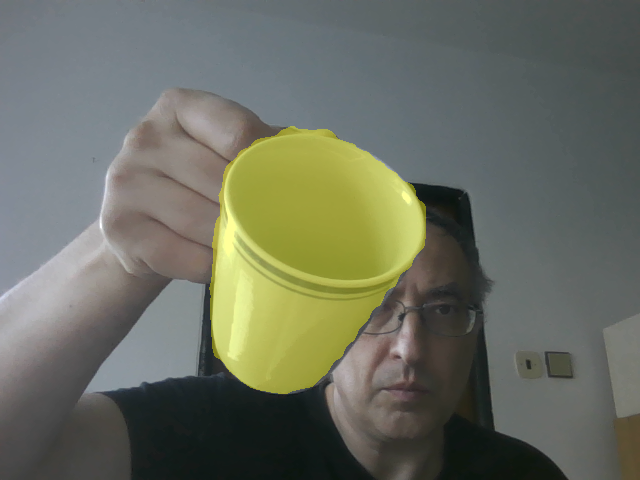

In [25]:
cv2_imshow_mask(image, fix_polarity(bipartition))

Our method without interpolation (lower resolution requires more iterations)

In [16]:
with torch.no_grad():
    blob = transform(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)).unsqueeze(0).to(device)
    feats = backbone.get_intermediate_layers(blob,norm=False)[0]
    feats = feats.view(feats.shape[0],blob.shape[2]//backbone.patch_size,blob.shape[3]//backbone.patch_size,feats.shape[-1])
    bipartition = ncut(feats, data_format="bhwc", num_iters=8)[0].cpu().numpy().astype(np.uint8)*255

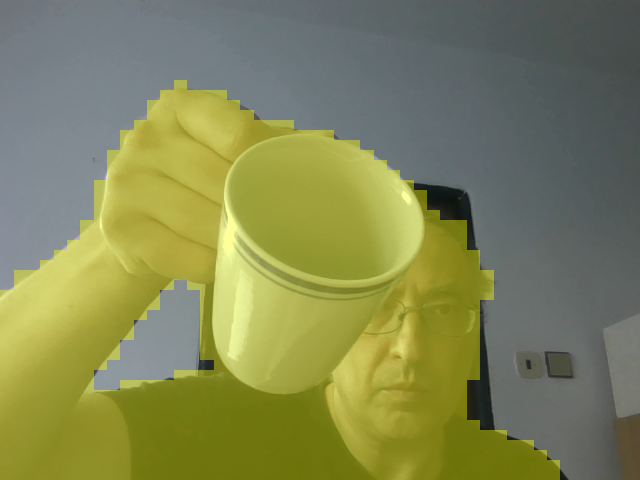

In [17]:
cv2_imshow_mask(image,cv2.resize(fix_polarity(bipartition),(image.shape[1],image.shape[0]),interpolation=cv2.INTER_NEAREST))

Comparision with the original algorithm (Shi & Malik 2000, Wang et. al 2023)

In [71]:
with torch.no_grad():
    blob = transform(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)).unsqueeze(0).to(device)
    feats = backbone.get_intermediate_layers(blob,norm=False)[0][0]

In [72]:
feats.shape

torch.Size([2304, 384])

In [73]:
48**2

2304

In [74]:
feats.norm(dim=1)

tensor([529.8472, 532.9237, 532.1339,  ..., 584.4850, 595.6140, 619.0229],
       device='cuda:0')

In [75]:
feats

tensor([[-25.9889,  23.1827,  54.6544,  ...,  19.1048, -46.0063, -27.9865],
        [-22.5001,  29.0616,  59.3935,  ...,  14.9205, -50.3841, -26.9465],
        [-22.5301,  27.6072,  54.9057,  ...,  11.5930, -51.4714, -22.7618],
        ...,
        [  5.6701,  13.6768,  55.6342,  ...,  16.1483,   6.0324, -27.9672],
        [  5.3143,  11.0622,  53.8668,  ...,  14.3861,  11.3807, -27.3600],
        [  2.1202,  22.1979,  46.8135,  ...,   4.2939,  17.7681, -26.9416]],
       device='cuda:0')

In [76]:
W = feats @ feats.t()

In [77]:
W.shape, W.min(), W.max()

(torch.Size([2304, 2304]),
 tensor(189572.7656, device='cuda:0'),
 tensor(479228.0312, device='cuda:0'))

- without thresholding

In [78]:
D = torch.diag(W.sum(dim=1))

In [79]:
torch.lobpcg(A=D-W, k=1, B=D, largest=True)[0]

tensor([1.0000], device='cuda:0')

In [80]:
eigenvalues, eigenvectors = torch.lobpcg(A=D-W, k=2, B=D, largest=False)

In [81]:
eigenvalues

tensor([-1.1663e-07,  9.3491e-01], device='cuda:0')

In [82]:
eigenvectors[:,1]

tensor([6.0497e-07, 6.2704e-07, 5.9700e-07,  ..., 6.6132e-07, 5.3204e-07,
        4.1309e-07], device='cuda:0')

In [83]:
bipartition = (eigenvectors[:,1] > 0).view(48,48).cpu().numpy().astype(np.uint8)*255

inverted


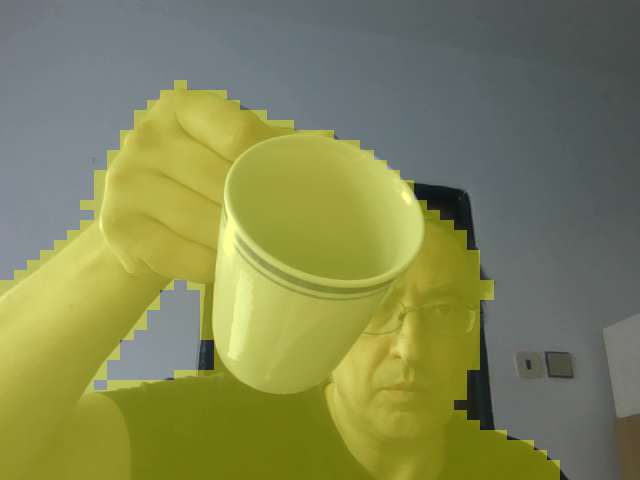

In [84]:
cv2_imshow_mask(image,cv2.resize(fix_polarity(bipartition),(image.shape[1],image.shape[0]),interpolation=cv2.INTER_NEAREST))

- with thresholding

In [85]:
WW = W.clone()
WW[WW<=0.0] = 1e-5
DD = torch.diag(WW.sum(dim=1))

In [86]:
eigenvalues, eigenvectors = torch.lobpcg(A=DD-WW, k=2, B=DD, largest=False)

In [87]:
eigenvalues

tensor([9.6309e-08, 9.3490e-01], device='cuda:0')

In [88]:
bipartition = (eigenvectors[:,1] > 0).view(48,48).cpu().numpy().astype(np.uint8)*255

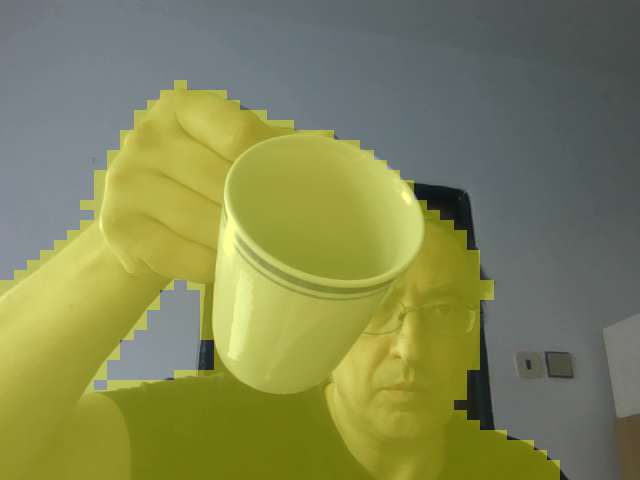

In [89]:
cv2_imshow_mask(image,cv2.resize(fix_polarity(bipartition),(image.shape[1],image.shape[0]),interpolation=cv2.INTER_NEAREST))